# Exploratory Data Analysis (EDA) for Joined Intermediate Data

This notebook loads the joined intermediate dataset (`joined_data.csv`), filters down to unique account numbers, and performs comprehensive EDA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load joined intermediate data
# Note: The dataset has ~287MB of data so it might take a moment to load
df = pd.read_csv('../../data/02_intermediate/joined_data.csv')

print(f"Original Dataset shape: {df.shape}")

# Consider only unique account numbers
# Keeping the 'last' entry assuming it might be the most recent if ordered, otherwise just deduplicating.
if 'account_number' in df.columns:
    original_len = len(df)
    df = df.drop_duplicates(subset=['account_number'], keep='last')
    print(f"Dropped {original_len - len(df)} duplicate/multiple account records.")
else:
    print("Warning: 'account_number' not found in columns. Skipping deduplication.")

print(f"Dataset shape after unique account filtering: {df.shape}")

print("\nFirst 5 rows:")
display(df.head())
print("\nColumns:", df.columns.tolist())


Original Dataset shape: (21526, 40)
Dropped 0 duplicate/multiple account records.
Dataset shape after unique account filtering: (21526, 40)

First 5 rows:


,account_number,pull_van,new_van,van,number_of_contracts,machines,number_of_repair_cases,number_of_overdueservices,product_bob,fee_bob,...,agreement_start_date,agreement_end_date_bob,renewal_type,agreement_type,line_of_business,billing_period,total_agreements,lost_agreements,active_agreements,churn_category
0,IE01-C2042480-L,0.0,0.0,1367.229308,1.0,1.0,0.09903,0.0,1322.315027,79.971669,...,2019-05-22,2025-12-31,Automatic Renewal,Scheduled Billing,Machine Services,monthly,0,0,0,2
1,IE01-C2048834-L,0.0,0.0,1844.208135,1.0,1.0,0.09903,0.0,1322.315027,79.971669,...,2019-05-22,2025-12-31,Automatic Renewal,Scheduled Billing,Machine Services,monthly,0,0,0,2
2,IE01-C2156428-L,0.0,0.0,2895.770682,1.0,1.0,0.09903,0.0,1322.315027,79.971669,...,2019-05-22,2025-12-31,Automatic Renewal,Scheduled Billing,Machine Services,monthly,0,0,0,2
3,IE01-C2244318-L,0.0,0.0,3496.011435,1.0,1.0,0.09903,0.0,1322.315027,79.971669,...,2019-05-22,2025-12-31,Automatic Renewal,Scheduled Billing,Machine Services,monthly,0,0,0,2
4,IE01-C2270501-L,0.0,0.0,928.175957,1.0,1.0,0.09903,0.0,1322.315027,79.971669,...,2019-05-22,2025-12-31,Automatic Renewal,Scheduled Billing,Machine Services,monthly,0,0,0,2



Columns: ['account_number', 'pull_van', 'new_van', 'van', 'number_of_contracts', 'machines', 'number_of_repair_cases', 'number_of_overdueservices', 'product_bob', 'fee_bob', 'total_bob', 'service_interval', 'unit_amount', 'billing_interval', 'case_title', 'branch', 'agreement_end_date', 'pull_type', 'case_type', 'risk', 'current_status', 'companysize', 'customer_tier', 'case_origin', 'case_creation_date', 'resolved_date', 'registered_date', 'expected_pull_date', 'company_sizing', 'branch_bob', 'agreement_start_date', 'agreement_end_date_bob', 'renewal_type', 'agreement_type', 'line_of_business', 'billing_period', 'total_agreements', 'lost_agreements', 'active_agreements', 'churn_category']


## Missing Values Analysis
Let's identify missing values across features.

In [2]:
# Calculate missing percentages
missing_percentages = df.isnull().mean() * 100
missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

if not missing_percentages.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_percentages.values, y=missing_percentages.index)
    plt.title('Percentage of Missing Values by Feature')
    plt.xlabel('Percentage (%)')
    plt.ylabel('Features')
    plt.show()
else:
    print("No missing values found!")

print("\nMissing Percentages:\n", missing_percentages)


No missing values found!

Missing Percentages:
 Series([], dtype: float64)


## Target Variable Analysis (`churn_category`)
Understanding the distribution of our primary target variable, `churn_category` per unique account.


Churn distribution:
churn_category
2    16233
0     4226
1     1067
Name: count, dtype: int64


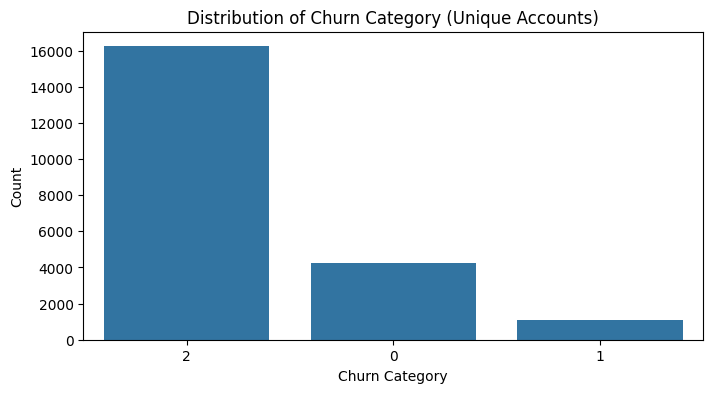

In [3]:
print("\nChurn distribution:")
churn_counts = df['churn_category'].value_counts(dropna=False)
print(churn_counts)

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='churn_category', order=df['churn_category'].value_counts().index)
plt.title('Distribution of Churn Category (Unique Accounts)')
plt.xlabel('Churn Category')
plt.ylabel('Count')
plt.show()


## Numeric Feature Distributions
Understanding the spread, outliers, and basic statistics in numeric features like agreement counts and billing amounts.


Numeric columns: ['pull_van', 'new_van', 'van', 'number_of_contracts', 'machines', 'number_of_repair_cases', 'number_of_overdueservices', 'product_bob', 'fee_bob', 'total_bob', 'service_interval', 'unit_amount', 'billing_interval', 'total_agreements', 'lost_agreements', 'active_agreements', 'churn_category']


,pull_van,new_van,van,number_of_contracts,machines,number_of_repair_cases,number_of_overdueservices,product_bob,fee_bob,total_bob,service_interval,unit_amount,billing_interval,total_agreements,lost_agreements,active_agreements,churn_category
count,21526.000000,21526.000000,21526.000000,21526.000000,21526.000000,21526.000000,21526.0,21526.000000,21526.000000,21526.000000,21526.000000,21526.000000,21526.000000,21526.000000,21526.000000,21526.000000,21526.000000
mean,1028.794202,1328.725788,2726.256131,1.167096,2.238550,0.099030,0.0,1322.315027,79.971669,1402.286696,14.457451,130.649229,1.055058,0.261451,0.065131,0.245889,1.557791
std,2253.630861,5308.104030,6038.668534,0.571289,2.804461,0.631058,0.0,966.883604,53.543364,996.665110,5.667684,110.946012,0.361273,0.439435,0.246762,0.430623,0.799582
min,0.000000,-1620.000000,0.000000,1.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,420.987658,1.000000,1.000000,0.000000,0.0,1322.315027,79.971669,1402.286696,14.457451,130.649229,1.055058,0.000000,0.000000,0.000000,2.000000
50%,311.040173,0.000000,1238.177144,1.000000,2.000000,0.000000,0.0,1322.315027,79.971669,1402.286696,14.457451,130.649229,1.055058,0.000000,0.000000,0.000000,2.000000
75%,1176.274758,572.288750,2838.915501,1.167096,2.238550,0.000000,0.0,1322.315027,79.971669,1402.286696,14.457451,130.649229,1.055058,1.000000,0.000000,0.000000,2.000000
max,78345.489925,166988.745810,175428.718810,35.000000,105.000000,33.000000,0.0,54030.114286,2157.840000,54941.394286,53.000000,4502.507143,12.000000,1.000000,1.000000,1.000000,2.000000


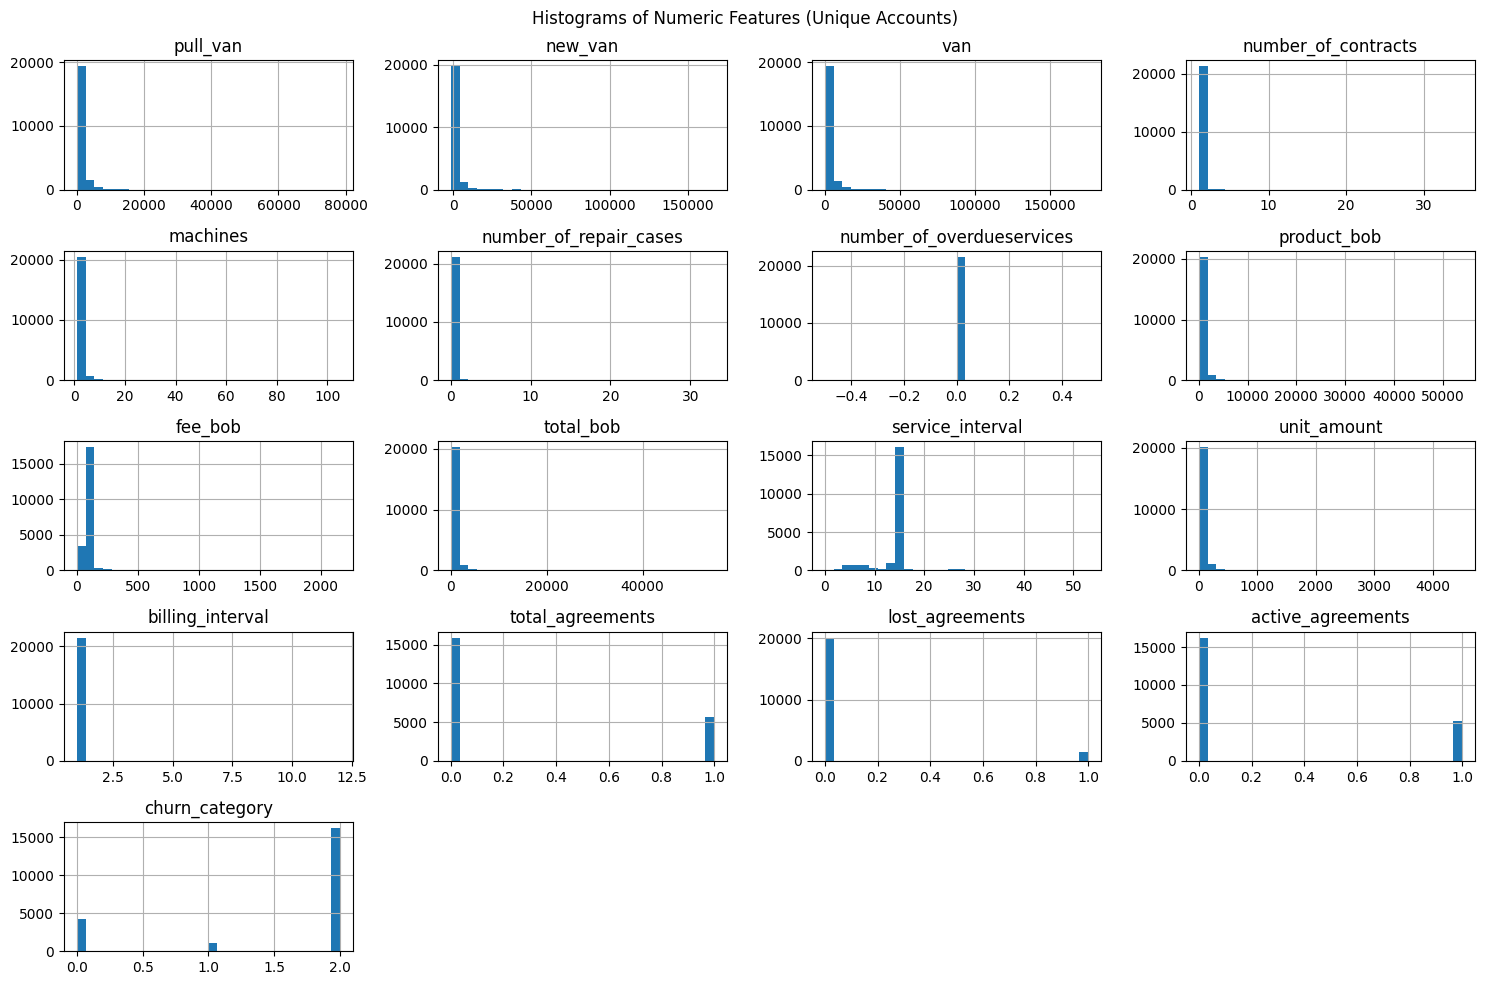

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(f"\nNumeric columns: {list(numeric_cols)}")

display(df[numeric_cols].describe())

df[numeric_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle('Histograms of Numeric Features (Unique Accounts)')
plt.tight_layout()
plt.show()


## Numeric Correlation Analysis
Let's see if numeric variables correlate strongly with each other, keeping an eye out for multicollinearity issues.

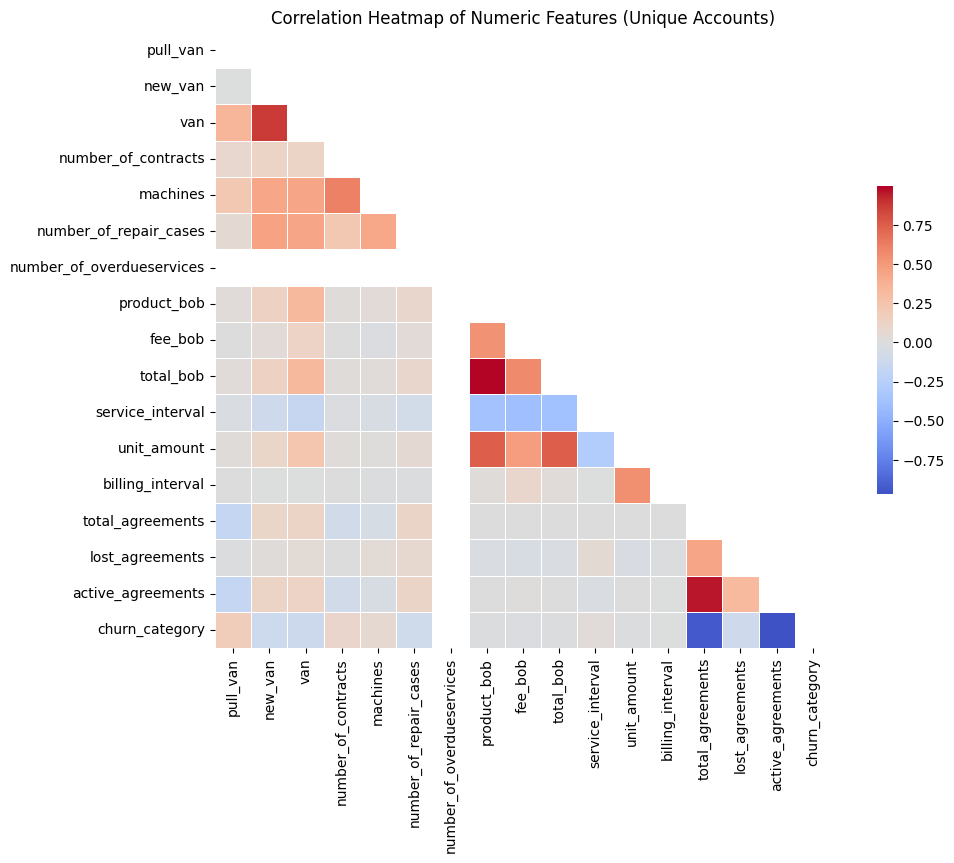

In [5]:
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.title('Correlation Heatmap of Numeric Features (Unique Accounts)')
plt.show()


## Categorical Feature Distributions
Looking at top categories string/object type columns.

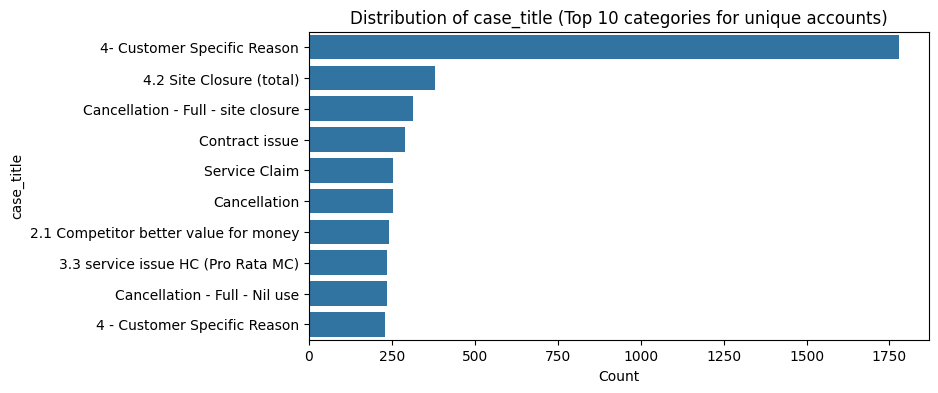

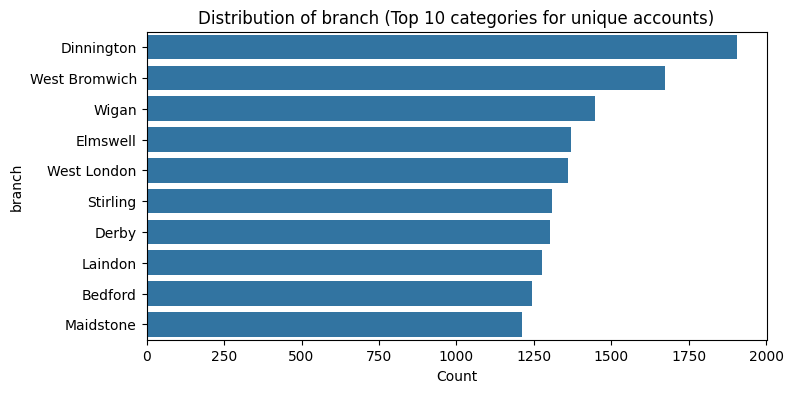

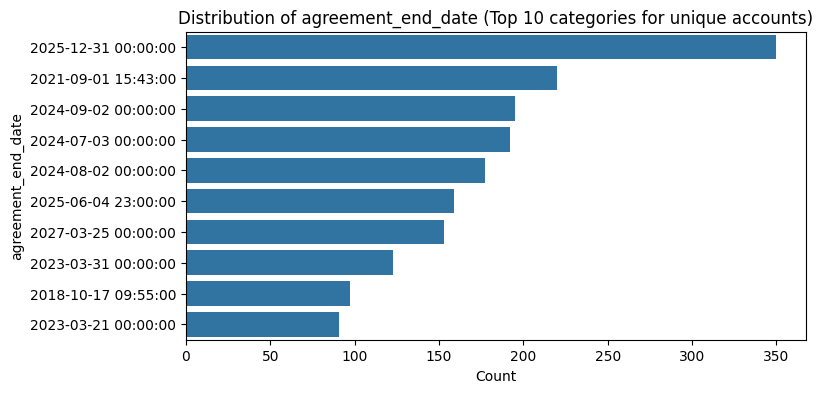

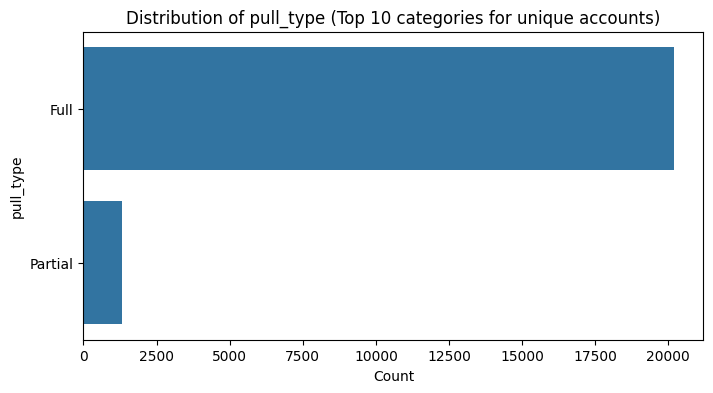

In [6]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols[1:5]: # Plot first 5 categorical columns as examples
    plt.figure(figsize=(8, 4))
    sns.countplot(y=df[col].astype(str), order=df[col].astype(str).value_counts().iloc[:10].index)
    plt.title(f'Distribution of {col} (Top 10 categories for unique accounts)')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()


## Categorical Feature Distributions & Churn Context
Analyzing how different categories relate to churn.

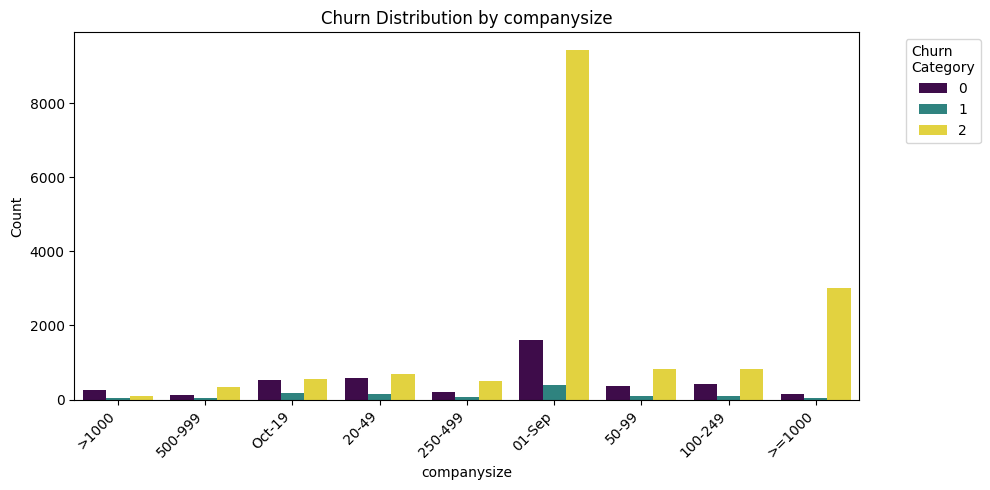

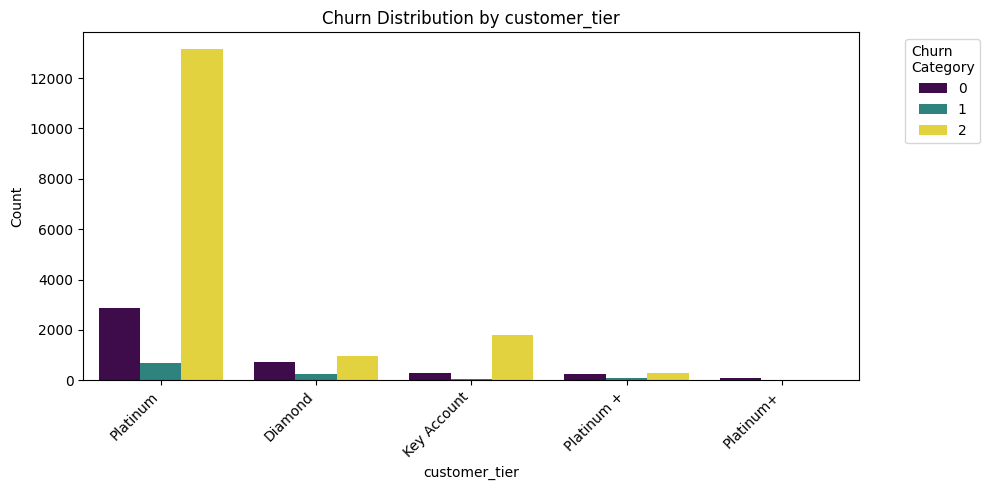

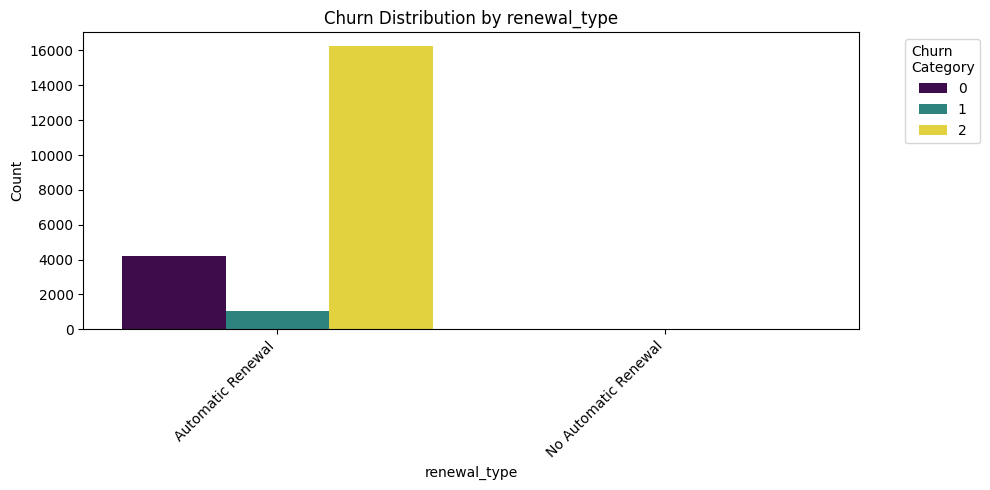

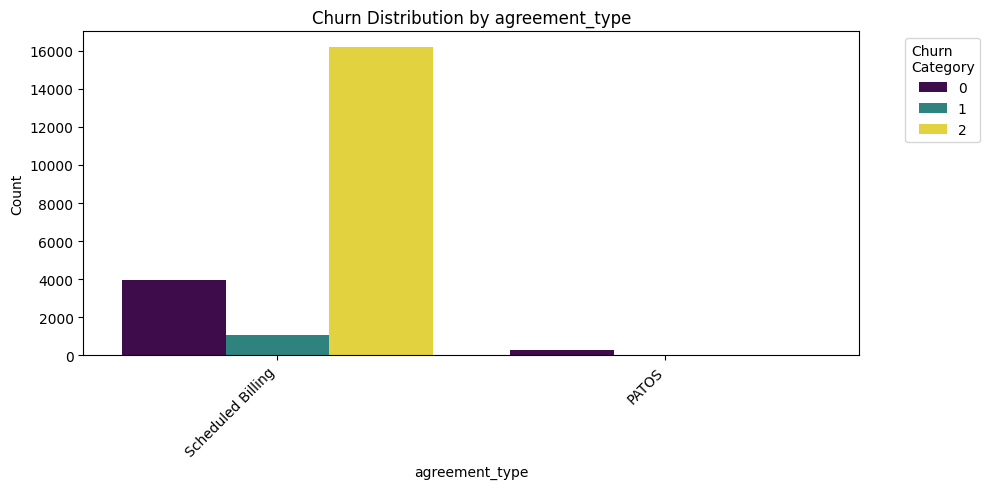

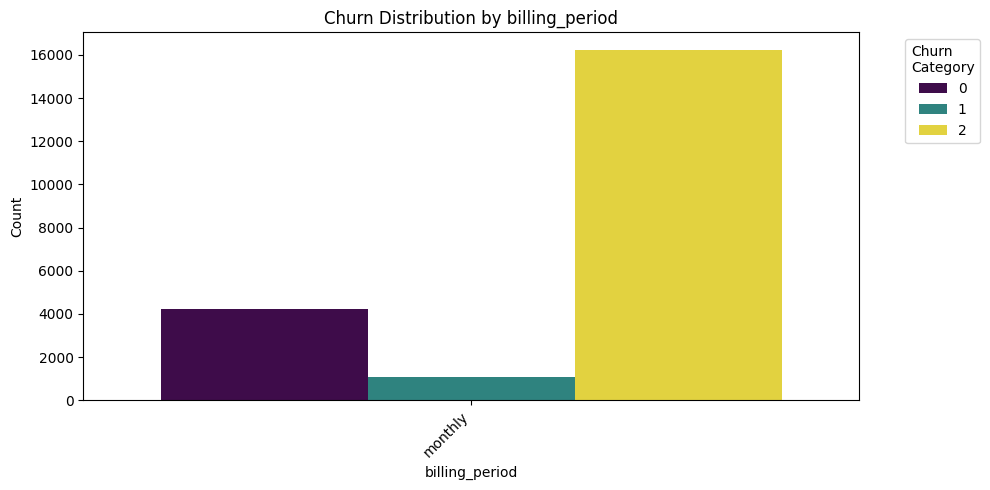

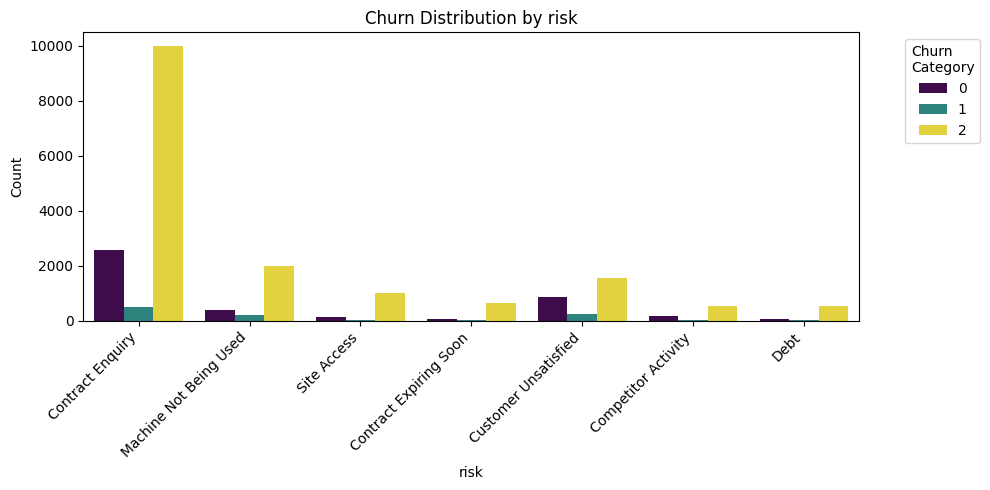

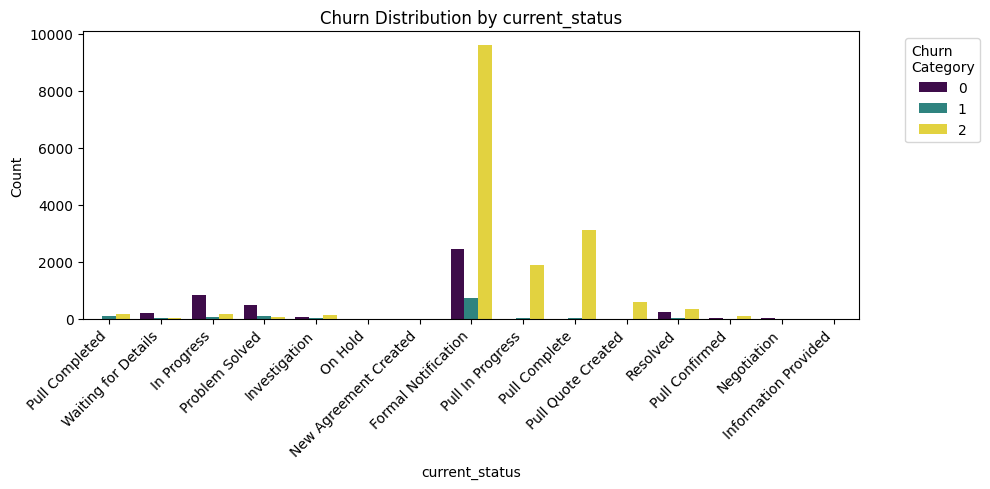

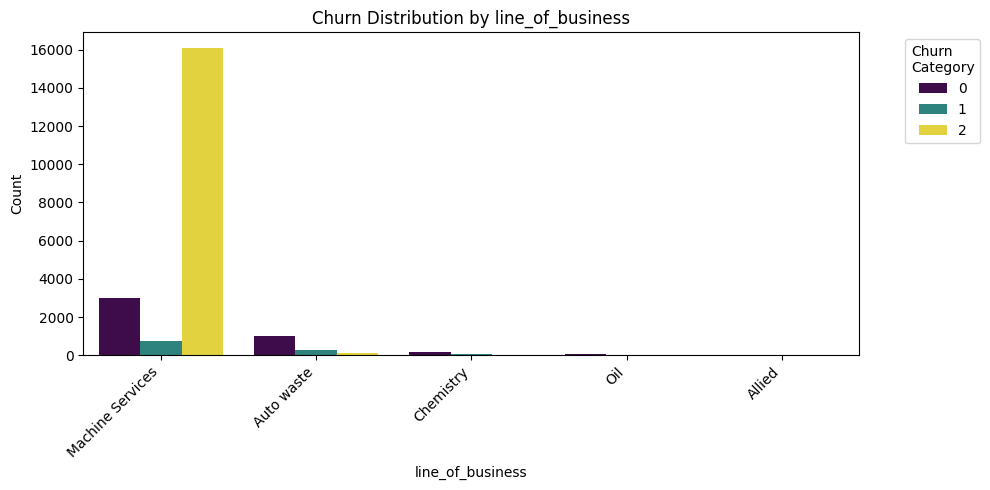

In [7]:
cat_cols = ['companysize', 'customer_tier', 'renewal_type', 'agreement_type', 'billing_period', 'risk', 'current_status', 'line_of_business']

# Plot categorical features showing the churn distribution
for col in cat_cols:
    if col in df.columns:
        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, x=col, hue='churn_category', palette='viridis')
        plt.title(f'Churn Distribution by {col}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Churn\nCategory', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

## Outlier Detection in Numeric Features
Visualizing outliers using boxplots for key continuous variables. This helps in understanding the spread and detecting any anomalies that might cause issues during modeling.

D:\temp\ipykernel_7120\3450165737.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=df['churn_category'].astype(str), orient='h', palette='Set2')


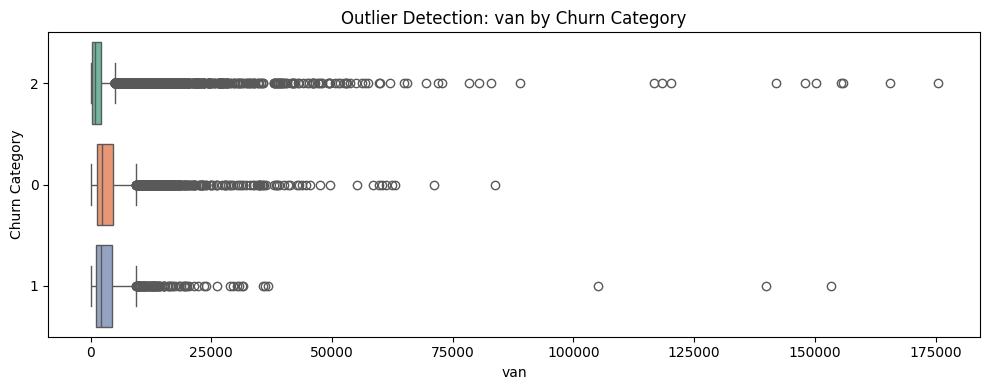

D:\temp\ipykernel_7120\3450165737.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=df['churn_category'].astype(str), orient='h', palette='Set2')


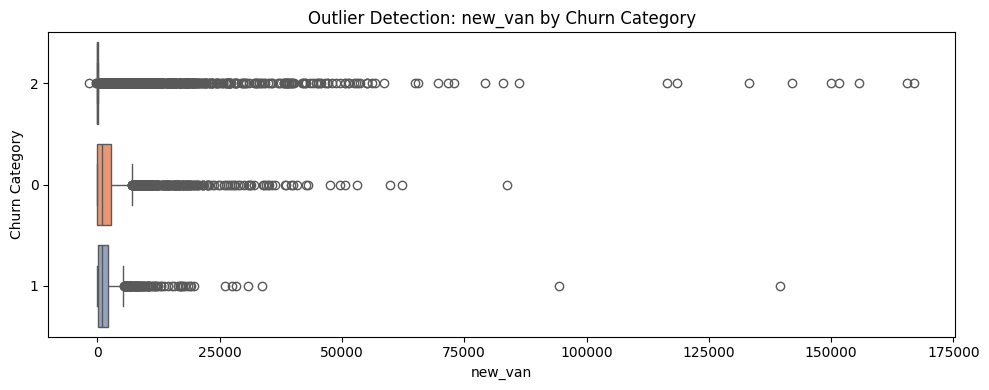

D:\temp\ipykernel_7120\3450165737.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=df['churn_category'].astype(str), orient='h', palette='Set2')


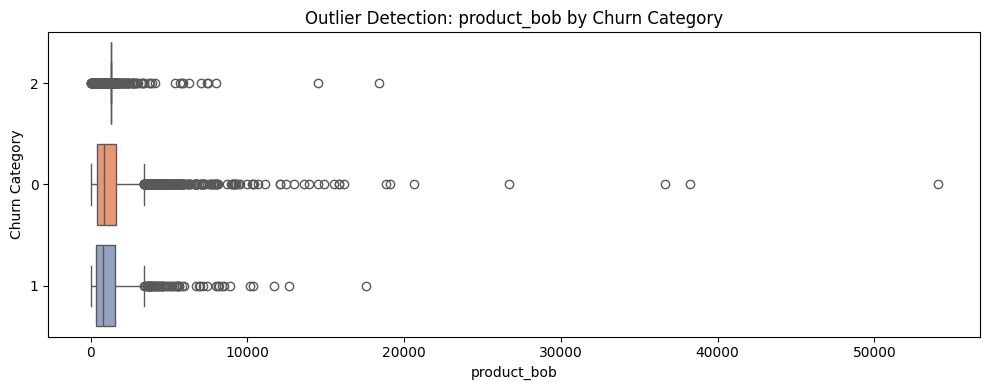

D:\temp\ipykernel_7120\3450165737.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=df['churn_category'].astype(str), orient='h', palette='Set2')


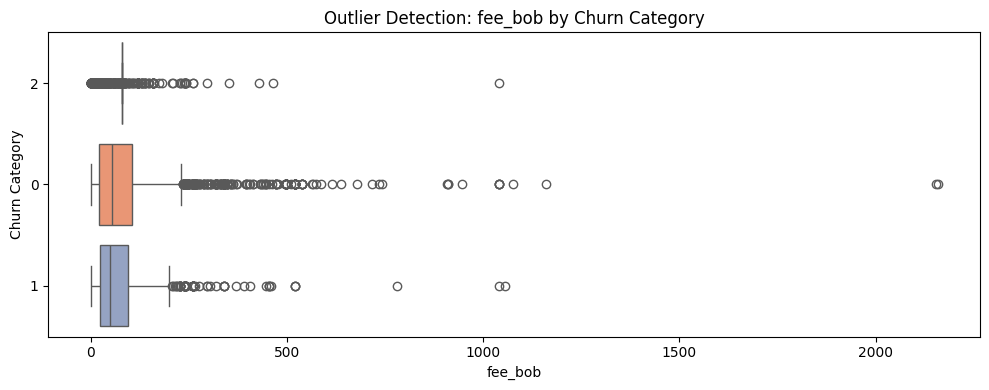

D:\temp\ipykernel_7120\3450165737.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=df['churn_category'].astype(str), orient='h', palette='Set2')


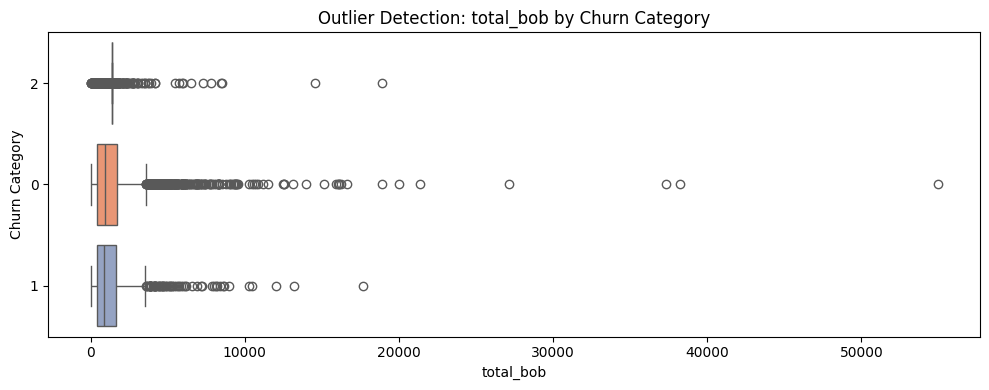

D:\temp\ipykernel_7120\3450165737.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=df['churn_category'].astype(str), orient='h', palette='Set2')


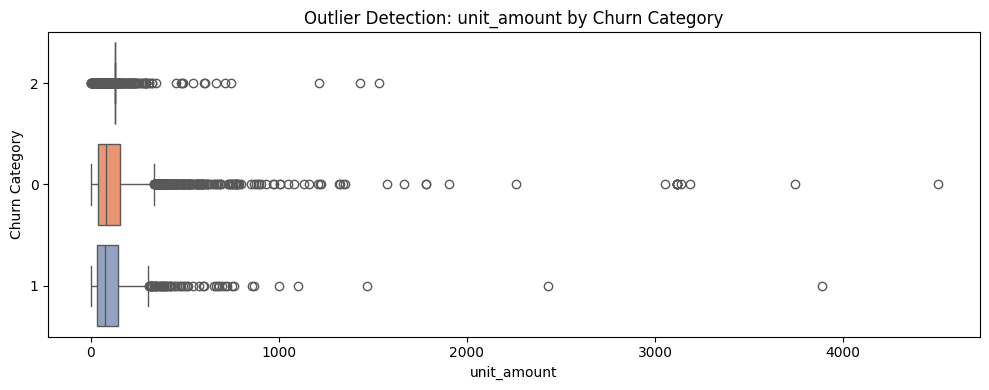

D:\temp\ipykernel_7120\3450165737.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=df['churn_category'].astype(str), orient='h', palette='Set2')


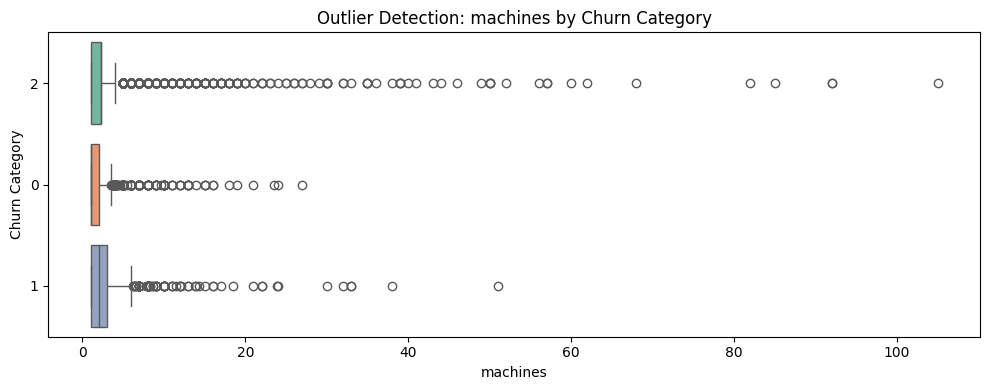

D:\temp\ipykernel_7120\3450165737.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y=df['churn_category'].astype(str), orient='h', palette='Set2')


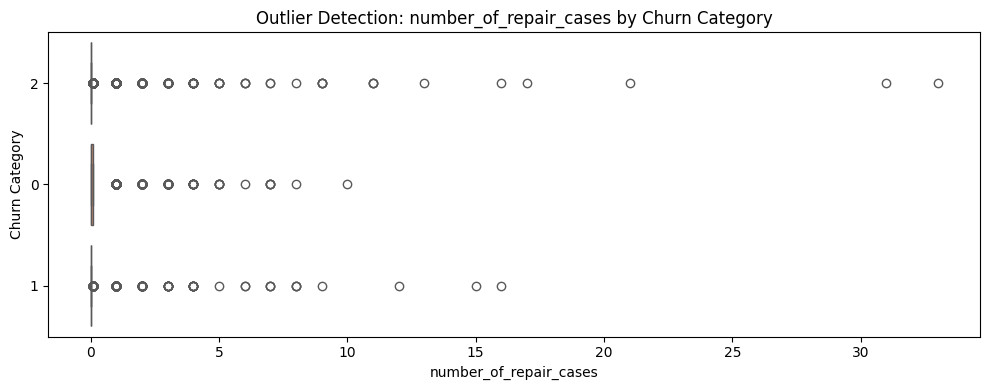

In [8]:
num_cols_for_outliers = ['van', 'new_van', 'product_bob', 'fee_bob', 'total_bob', 'unit_amount', 'machines', 'number_of_repair_cases']

for col in num_cols_for_outliers:
    if col in df.columns:
        plt.figure(figsize=(10, 4))
        sns.boxplot(data=df, x=col, y=df['churn_category'].astype(str), orient='h', palette='Set2')
        plt.title(f'Outlier Detection: {col} by Churn Category')
        plt.xlabel(col)
        plt.ylabel('Churn Category')
        plt.tight_layout()
        plt.show()

## Outlier Treatment Strategy
Based on the boxplots, if extreme outliers exist (such as total_bob or van reaching suspiciously high numbers), we may cap them using interquartile ranges (IQR) or 99th percentile capping before training the models.

## Correlation Matrix & Multivariate Analysis
Looking for highly correlated features or those strongly correlated with churn_category.

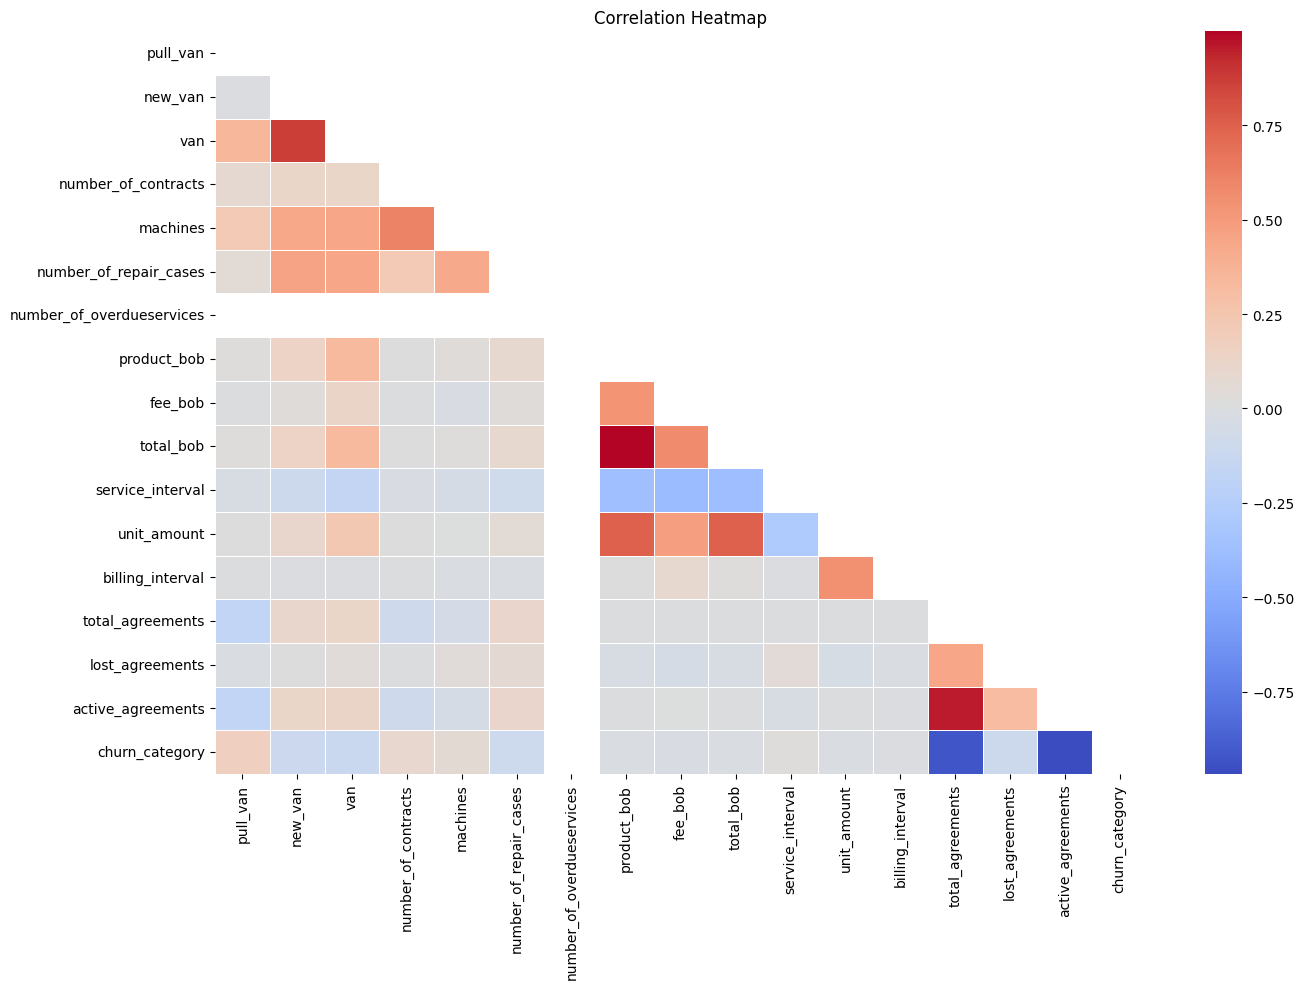

Correlation with Churn Category:
pull_van                     0.175394
number_of_contracts          0.097337
machines                     0.063089
service_interval             0.028933
billing_interval            -0.002581
product_bob                 -0.012667
unit_amount                 -0.012811
total_bob                   -0.013248
fee_bob                     -0.017862
number_of_repair_cases      -0.094431
lost_agreements             -0.105256
new_van                     -0.114025
van                         -0.122395
total_agreements            -0.929543
active_agreements           -0.968553
number_of_overdueservices         NaN
Name: churn_category, dtype: float64

--- OBSERVATION ---
The features with the highest absolute correlation values should be closely monitored.
Notice any multicollinearity (features heavily correlated with each other, like total_bob and fee_bob/product_bob). We may drop highly collinear features later.


In [9]:
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
# Mask upper triangle to make the heatmap prettier
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Top correlations with churn
if 'churn_category' in corr.columns:
    churn_corr = corr['churn_category'].drop('churn_category').sort_values(ascending=False)
    print("Correlation with Churn Category:")
    print(churn_corr)
    
    print("\n--- OBSERVATION ---")
    print("The features with the highest absolute correlation values should be closely monitored.")
    print("Notice any multicollinearity (features heavily correlated with each other, like total_bob and fee_bob/product_bob). We may drop highly collinear features later.")

## Deep Dive: Feature Importance & Separation (Bivariate Analysis)
Looking closer at how specific numeric features differ between churned and non-churned clients.

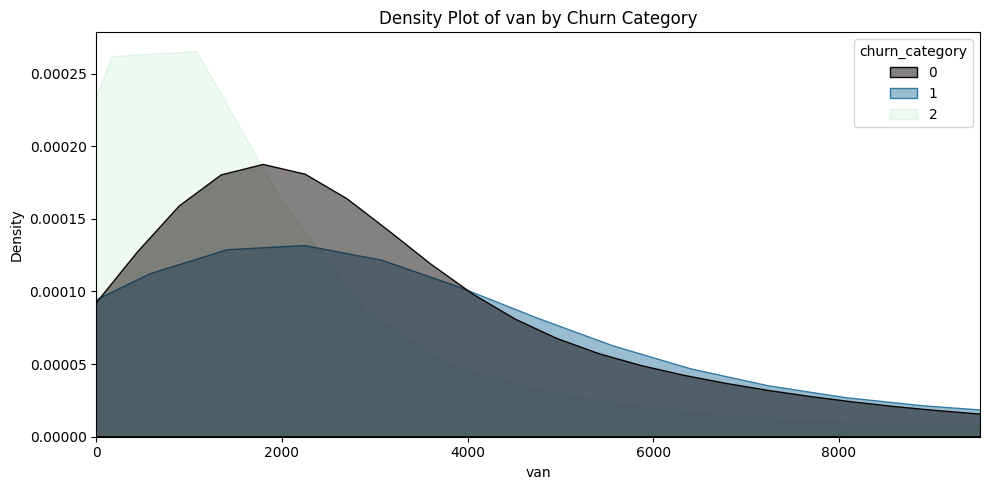

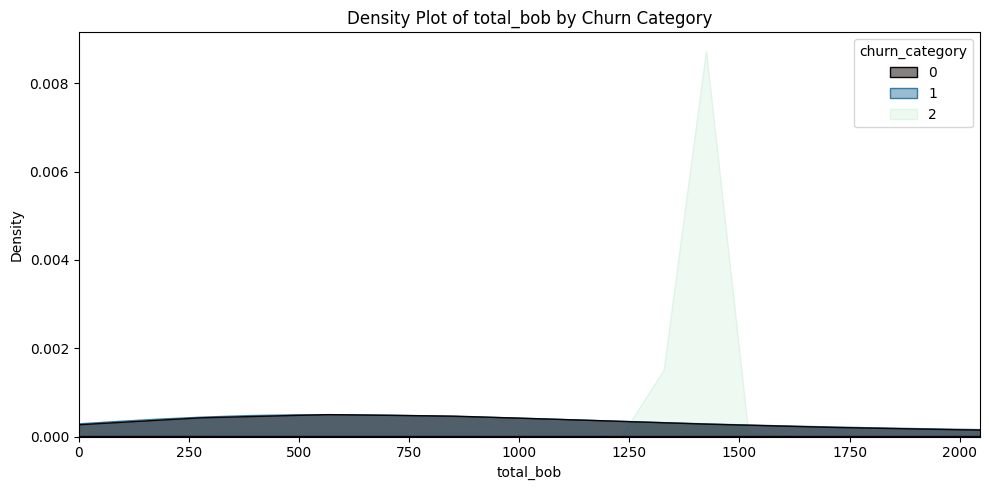

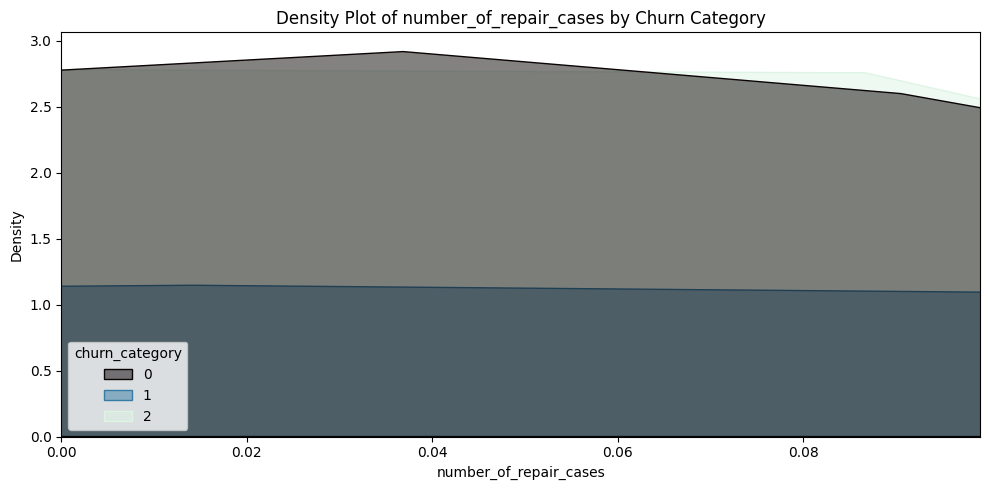

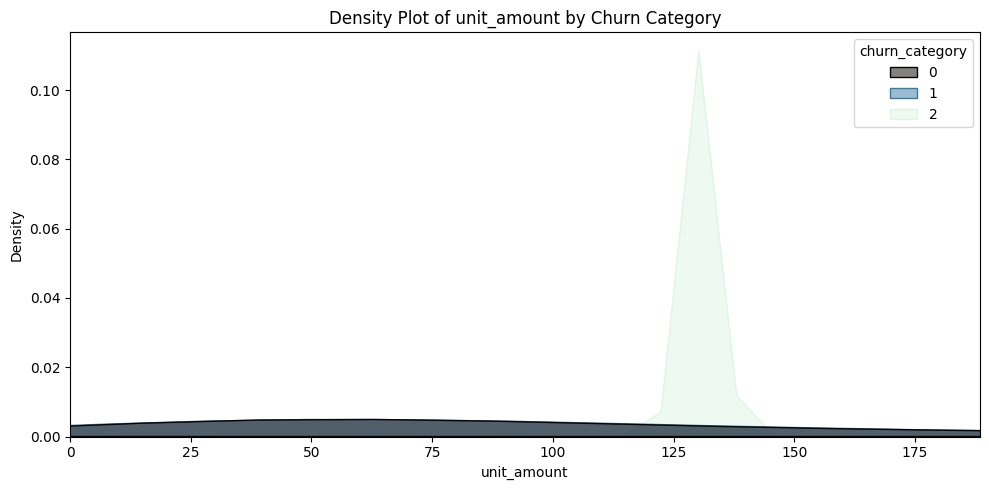

In [10]:
key_features = ['van', 'total_bob', 'number_of_repair_cases', 'unit_amount']

for col in key_features:
    if col in df.columns:
        plt.figure(figsize=(10, 5))
        sns.kdeplot(data=df, x=col, hue='churn_category', fill=True, common_norm=False, palette='mako', alpha=0.5)
        plt.title(f'Density Plot of {col} by Churn Category')
        plt.xlabel(col)
        plt.ylabel('Density')
        # Set x limits to 95th percentile to avoid heavily outlier-skewed density plots
        q95 = df[col].quantile(0.95)
        plt.xlim(0, q95 if q95 > 0 else df[col].max())
        plt.tight_layout()
        plt.show()

## Data Imbalance Checking
Understanding the proportion of classes within our target variable `churn_category`.

In [11]:
churn_proportions = df['churn_category'].value_counts(normalize=True) * 100
print("Churn Category Proportions (%):")
print(churn_proportions)

print("\n--- OBSERVATION ---")
print("The target variable exhibits data imbalance. The majority class forms a significant chunk of the dataset.")
print("To handle this during modeling, we should explore addressing the imbalance using methods like:")
print("1. Class weights in our chosen algorithm.")
print("2. Over-sampling minority classes (SMOTE).\n3. Under-sampling majority class.")
print("Additionally, accuracy won't be a reliable metric; F1-score or PR-AUC should be monitored.")

Churn Category Proportions (%):
churn_category
2    75.411131
0    19.632073
1     4.956796
Name: proportion, dtype: float64

--- OBSERVATION ---
The target variable exhibits data imbalance. The majority class forms a significant chunk of the dataset.
To handle this during modeling, we should explore addressing the imbalance using methods like:
1. Class weights in our chosen algorithm.
2. Over-sampling minority classes (SMOTE).
3. Under-sampling majority class.
Additionally, accuracy won't be a reliable metric; F1-score or PR-AUC should be monitored.
